# Hospital Readmissions Analysis — CMS FY 2026 Data

This project analyzes two public datasets from the Centers for Medicare & Medicaid Services (CMS) to explore how hospital readmission performance varies by **state**, **quality rating**, **medical condition**, and **ownership type**.

**Data sources** (CMS Hospital Compare / Care Compare, FY 2026 releases):
- `FY_2026_Hospital_Readmissions_Reduction_Program_Hospital.csv` — excess readmission ratios and penalty-program data for ~3,000 hospitals across 6 conditions (heart attack, heart failure, pneumonia, COPD, bypass surgery, hip/knee replacement).
- `Hospital_General_Information.csv` — hospital-level metadata: overall star rating, ownership type, location, and services.

**What "Excess Readmission Ratio" means:** it's the ratio of a hospital's *predicted* 30-day readmission rate to its *expected* readmission rate, given its patient mix. A ratio **above 1.0** means the hospital readmits more patients than expected for a hospital with a similar case mix; **below 1.0** means fewer than expected (better performance).

**Approach:** load both CSVs into a local SQLite database, clean the data, then answer four business questions using SQL (via Python), with a handful of visualizations to illustrate the findings.

**Questions this notebook answers:**
1. Which states have the highest average excess readmission ratios?
2. Do hospitals with higher star ratings have lower readmission ratios?
3. Which condition shows the most variation in readmission performance across hospitals?
4. Does hospital ownership type correlate with readmission performance?

**Tools:** Python, pandas, SQLite (`sqlite3`), matplotlib.

## 1. Setup

Standard imports: `pandas` for data wrangling, `sqlite3` for the database, `re` for the column-name cleanup, and `matplotlib` for charts. `pathlib.Path` keeps our file paths portable regardless of who clones this repo.

In [1]:
import re
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This notebook lives in notebooks/, and the source CSVs live one level up
# in the project root — DATA_DIR keeps every path relative, so the notebook
# runs the same way for anyone who clones the repo.
DATA_DIR = Path("..")
DB_PATH = DATA_DIR / "hospital_readmissions.db"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

## 2. Load the Raw CSVs

We read both files first without any transformation, so we can see exactly what CMS gives us — including the messy parts (inconsistent capitalization, spaces in column names, and text sentinel values like `"Too Few to Report"` mixed into numeric columns).

One detail matters immediately: `Facility ID` (e.g. `010001`) has a leading zero. If we let pandas auto-infer its type, it gets read as an integer and the leading zero is silently dropped — which would break joins between the two files down the line. We load it explicitly as a string (`dtype={"Facility ID": str}`) in both files to prevent that.

In [2]:
readm_raw = pd.read_csv(
    DATA_DIR / "FY_2026_Hospital_Readmissions_Reduction_Program_Hospital.csv",
    dtype={"Facility ID": str},
)
gen_raw = pd.read_csv(
    DATA_DIR / "Hospital_General_Information.csv",
    dtype={"Facility ID": str},
)

print(f"Readmissions file:  {readm_raw.shape[0]:,} rows x {readm_raw.shape[1]} columns")
print(f"General info file:  {gen_raw.shape[0]:,} rows x {gen_raw.shape[1]} columns")
readm_raw.head(3)

Readmissions file:  18,330 rows x 12 columns
General info file:  5,432 rows x 38 columns


,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-CABG-HRRP,137.0,NaN,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-AMI-HRRP,273.0,NaN,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024


## 3. Clean Column Names

CMS column names like `"Excess Readmission Ratio"` and `"City/Town"` aren't SQL-friendly — spaces and slashes cause problems when writing queries. We write one small function that:

1. Lowercases the name
2. Replaces any run of non-alphanumeric characters (spaces, `/`, `-`, etc.) with a single underscore
3. Trims leading/trailing underscores

So `"Excess Readmission Ratio"` → `excess_readmission_ratio` and `"City/Town"` → `city_town`. We apply it to both dataframes.

In [3]:
def clean_column_name(col: str) -> str:
    col = col.strip().lower()
    col = re.sub(r"[^0-9a-z]+", "_", col)
    col = col.strip("_")
    return col


readm = readm_raw.copy()
gen = gen_raw.copy()
readm.columns = [clean_column_name(c) for c in readm.columns]
gen.columns = [clean_column_name(c) for c in gen.columns]

print("Readmissions columns:", readm.columns.tolist())
print()
print("General info columns:", gen.columns.tolist())

Readmissions columns: ['facility_name', 'facility_id', 'state', 'measure_name', 'number_of_discharges', 'footnote', 'excess_readmission_ratio', 'predicted_readmission_rate', 'expected_readmission_rate', 'number_of_readmissions', 'start_date', 'end_date']

General info columns: ['facility_id', 'facility_name', 'address', 'city_town', 'state', 'zip_code', 'county_parish', 'telephone_number', 'hospital_type', 'hospital_ownership', 'emergency_services', 'meets_criteria_for_birthing_friendly_designation', 'hospital_overall_rating', 'hospital_overall_rating_footnote', 'mort_group_measure_count', 'count_of_facility_mort_measures', 'count_of_mort_measures_better', 'count_of_mort_measures_no_different', 'count_of_mort_measures_worse', 'mort_group_footnote', 'safety_group_measure_count', 'count_of_facility_safety_measures', 'count_of_safety_measures_better', 'count_of_safety_measures_no_different', 'count_of_safety_measures_worse', 'safety_group_footnote', 'readm_group_measure_count', 'count_of_

## 4. Clean and Type the Data

Two things need fixing before this data is analysis-ready:

**Sentinel values instead of nulls.** CMS uses text placeholders instead of leaving cells blank:
- `number_of_readmissions` contains the string `"Too Few to Report"` wherever CMS suppressed a small count for privacy — we convert that to a real `NULL`.
- `number_of_discharges` uses `"N/A"`, which pandas already recognizes as null automatically.
- `hospital_overall_rating` uses the string `"Not Available"` for hospitals CMS hasn't rated — same treatment.

We coerce all of these to numeric with `errors="coerce"`, which turns anything non-numeric into `NaN` — a safe choice here since we've already confirmed the only non-numeric values are the sentinels above (never a data-entry typo).

**Friendly condition labels.** The `measure_name` column uses codes like `READM-30-HIP-KNEE-HRRP`. We map these to readable labels (e.g. "Hip/Knee Replacement") so charts and tables are self-explanatory to anyone reading this notebook.

In [4]:
# --- Readmissions table ---
readm["number_of_readmissions"] = readm["number_of_readmissions"].replace(
    "Too Few to Report", pd.NA
)
readm["number_of_readmissions"] = pd.to_numeric(readm["number_of_readmissions"], errors="coerce")
readm["number_of_discharges"] = pd.to_numeric(readm["number_of_discharges"], errors="coerce")
readm["excess_readmission_ratio"] = pd.to_numeric(readm["excess_readmission_ratio"], errors="coerce")
readm["predicted_readmission_rate"] = pd.to_numeric(readm["predicted_readmission_rate"], errors="coerce")
readm["expected_readmission_rate"] = pd.to_numeric(readm["expected_readmission_rate"], errors="coerce")

condition_map = {
    "READM-30-AMI-HRRP": "AMI (Heart Attack)",
    "READM-30-CABG-HRRP": "CABG (Bypass Surgery)",
    "READM-30-COPD-HRRP": "COPD",
    "READM-30-HF-HRRP": "Heart Failure",
    "READM-30-HIP-KNEE-HRRP": "Hip/Knee Replacement",
    "READM-30-PN-HRRP": "Pneumonia",
}
readm["condition"] = readm["measure_name"].map(condition_map)

# --- General info table ---
gen["hospital_overall_rating"] = pd.to_numeric(gen["hospital_overall_rating"], errors="coerce")

print(f"Rows with a usable excess_readmission_ratio: {readm['excess_readmission_ratio'].notna().sum():,} "
      f"of {len(readm):,} ({readm['excess_readmission_ratio'].notna().mean():.0%})")
print()
print("Condition breakdown:")
print(readm["condition"].value_counts())
print()
print("Star rating distribution:")
print(gen["hospital_overall_rating"].value_counts(dropna=False).sort_index())

Rows with a usable excess_readmission_ratio: 11,720 of 18,330 (64%)

Condition breakdown:
condition
Hip/Knee Replacement     3055
CABG (Bypass Surgery)    3055
AMI (Heart Attack)       3055
COPD                     3055
Pneumonia                3055
Heart Failure            3055
Name: count, dtype: int64

Star rating distribution:
hospital_overall_rating
1.0     199
2.0     662
3.0     987
4.0     950
5.0     384
NaN    2250
Name: count, dtype: int64


## 5. Build the SQLite Database

Now we write both cleaned dataframes into a local SQLite file (`hospital_readmissions.db`, created in the project root). `DataFrame.to_sql` handles the table creation and insert for us. We also add indexes on the join/filter columns (`facility_id`, `state`) — with ~18K and ~5K rows this isn't strictly necessary for speed, but it's good practice and mirrors what you'd do with a larger table.

In [5]:
conn = sqlite3.connect(DB_PATH)

readm.to_sql("readmissions", conn, index=False, if_exists="replace")
gen.to_sql("hospital_general_info", conn, index=False, if_exists="replace")

conn.execute("CREATE INDEX IF NOT EXISTS idx_readm_facility_id ON readmissions(facility_id)")
conn.execute("CREATE INDEX IF NOT EXISTS idx_readm_state ON readmissions(state)")
conn.execute("CREATE INDEX IF NOT EXISTS idx_gen_facility_id ON hospital_general_info(facility_id)")
conn.commit()

print(f"Database written to: {DB_PATH.resolve()}")

Database written to: /Users/erintjordan/Desktop/Healthcare_CMS/hospital_readmissions.db


## 6. Quick Sanity Check

Before trusting any analysis, we confirm the database looks the way we expect: the right tables exist, and row counts match what we loaded.

In [6]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Tables in the database:", tables["name"].tolist())
print()

for table in ["readmissions", "hospital_general_info"]:
    n = pd.read_sql(f"SELECT COUNT(*) AS n FROM {table}", conn)["n"][0]
    print(f"{table}: {n:,} rows")

Tables in the database: ['readmissions', 'hospital_general_info']

readmissions: 18,330 rows
hospital_general_info: 5,432 rows


## 7. Analysis

With the data loaded and clean, we can answer the four questions using SQL. Each question below runs a query against the SQLite database with `pandas.read_sql`, which executes the SQL and returns the result as a dataframe.

### Q1: Which states have the highest average excess readmission ratios?

We average `excess_readmission_ratio` across all hospitals and conditions within each state. The `HAVING COUNT(*) >= 30` filter drops states with too few measurements (e.g. small territories) to produce a stable average — without it, a state with only 2-3 records could land at the top or bottom purely by chance.

In [7]:
q1_top_states = pd.read_sql("""
    SELECT
        state,
        ROUND(AVG(excess_readmission_ratio), 4) AS avg_excess_ratio,
        COUNT(*) AS n_measures
    FROM readmissions
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY state
    HAVING COUNT(*) >= 30
    ORDER BY avg_excess_ratio DESC
    LIMIT 15
""", conn)

q1_bottom_states = pd.read_sql("""
    SELECT
        state,
        ROUND(AVG(excess_readmission_ratio), 4) AS avg_excess_ratio,
        COUNT(*) AS n_measures
    FROM readmissions
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY state
    HAVING COUNT(*) >= 30
    ORDER BY avg_excess_ratio ASC
    LIMIT 5
""", conn)

print("Top 15 states (highest average excess readmission ratio — worse performance):")
display(q1_top_states)
print("\nBottom 5 states (lowest average excess readmission ratio — better performance):")
display(q1_bottom_states)

Top 15 states (highest average excess readmission ratio — worse performance):


,state,avg_excess_ratio,n_measures
0,MA,1.0344,240
1,NJ,1.0277,272
2,FL,1.0229,771
3,IL,1.0194,491
4,MS,1.0141,185
5,AL,1.0139,247
6,WV,1.0115,95
7,GA,1.0114,346
8,NV,1.0114,94
9,CA,1.0101,1038



Bottom 5 states (lowest average excess readmission ratio — better performance):


,state,avg_excess_ratio,n_measures
0,ID,0.9432,56
1,ND,0.9466,35
2,ME,0.9515,49
3,MT,0.9541,53
4,UT,0.9559,99


**Finding:** Massachusetts has the highest average excess readmission ratio (1.034), followed by New Jersey (1.028) and Florida (1.023) — all Northeast/Southeast states with dense, high-population hospital markets. At the other end, Idaho (0.943), North Dakota (0.947), and Maine (0.952) have the lowest ratios. The spread across states is real but modest — the worst-performing state is only about 9 percentage points worse than the best, which suggests readmission performance is driven more by hospital-level and condition-level factors than by geography alone (we explore both next).

### Q2: Do hospitals with higher star ratings have lower readmission ratios?

This question needs a join. The readmissions table has multiple rows per hospital (one per condition), so we first collapse it to one average `excess_readmission_ratio` per `facility_id` in a CTE (`hospital_avg`), then join that to `hospital_general_info` to bring in `hospital_overall_rating`. Grouping by rating gives us the average ratio at each star level.

In [8]:
q2_by_rating = pd.read_sql("""
    WITH hospital_avg AS (
        SELECT facility_id, AVG(excess_readmission_ratio) AS avg_excess_ratio
        FROM readmissions
        WHERE excess_readmission_ratio IS NOT NULL
        GROUP BY facility_id
    )
    SELECT
        g.hospital_overall_rating,
        COUNT(*) AS n_hospitals,
        ROUND(AVG(h.avg_excess_ratio), 4) AS avg_excess_ratio
    FROM hospital_avg h
    JOIN hospital_general_info g ON h.facility_id = g.facility_id
    WHERE g.hospital_overall_rating IS NOT NULL
    GROUP BY g.hospital_overall_rating
    ORDER BY g.hospital_overall_rating
""", conn)

display(q2_by_rating)

# Pearson correlation at the individual-hospital level (not just the group averages above)
hospital_level = pd.read_sql("""
    WITH hospital_avg AS (
        SELECT facility_id, AVG(excess_readmission_ratio) AS avg_excess_ratio
        FROM readmissions
        WHERE excess_readmission_ratio IS NOT NULL
        GROUP BY facility_id
    )
    SELECT h.avg_excess_ratio, g.hospital_overall_rating
    FROM hospital_avg h
    JOIN hospital_general_info g ON h.facility_id = g.facility_id
    WHERE g.hospital_overall_rating IS NOT NULL
""", conn)

corr = np.corrcoef(hospital_level["hospital_overall_rating"], hospital_level["avg_excess_ratio"])[0, 1]
print(f"\nPearson correlation (star rating vs. avg excess readmission ratio), n={len(hospital_level):,} hospitals: {corr:.4f}")

,hospital_overall_rating,n_hospitals,avg_excess_ratio
0,1.0,170,1.0452
1,2.0,568,1.0230
2,3.0,842,1.0058
3,4.0,761,0.9861
4,5.0,287,0.9642



Pearson correlation (star rating vs. avg excess readmission ratio), n=2,628 hospitals: -0.4422


**Finding:** Yes, clearly. The relationship is monotonic — average excess readmission ratio drops at every step from 1-star hospitals (1.045) down to 5-star hospitals (0.964). The Pearson correlation across all 2,628 individually-rated hospitals is **r ≈ -0.44**, a moderate negative relationship. That's not perfect (star rating also reflects mortality, safety, and patient experience — readmissions is only one of five component groups), but it confirms CMS's overall star rating is a meaningful proxy for readmission performance specifically, not just a noisy composite.

### Q3: Which condition shows the most variation across hospitals?

SQLite doesn't ship a built-in `STDEV()` function, but we don't need one — variance has a well-known algebraic identity:

$$\text{Var}(X) = E[X^2] - (E[X])^2$$

So `AVG(x*x) - AVG(x)*AVG(x)` computes the population variance directly in SQL. We take the square root in pandas afterward to get the standard deviation.

We also compute the **coefficient of variation** (`std / mean`) rather than relying on standard deviation alone. Since every condition's mean ratio is close to 1.0, in this case CV and standard deviation tell the same story — but CV is the more defensible metric in general, since it normalizes for scale and lets us compare variability fairly even when means differ.

In [9]:
q3_variation = pd.read_sql("""
    SELECT
        condition,
        COUNT(*) AS n_hospitals,
        AVG(excess_readmission_ratio) AS mean_ratio,
        AVG(excess_readmission_ratio * excess_readmission_ratio)
            - AVG(excess_readmission_ratio) * AVG(excess_readmission_ratio) AS variance_ratio,
        MIN(excess_readmission_ratio) AS min_ratio,
        MAX(excess_readmission_ratio) AS max_ratio
    FROM readmissions
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY condition
""", conn)

q3_variation["std_ratio"] = np.sqrt(q3_variation["variance_ratio"])
q3_variation["coefficient_of_variation"] = q3_variation["std_ratio"] / q3_variation["mean_ratio"]
q3_variation = q3_variation.sort_values("coefficient_of_variation", ascending=False).round(4)

q3_variation[["condition", "n_hospitals", "mean_ratio", "std_ratio", "coefficient_of_variation", "min_ratio", "max_ratio"]]

,condition,n_hospitals,mean_ratio,std_ratio,coefficient_of_variation,min_ratio,max_ratio
4,Hip/Knee Replacement,1447,1.0040,0.1556,0.1550,0.4698,1.6297
1,CABG (Bypass Surgery),878,1.0018,0.0965,0.0963,0.7434,1.4237
0,AMI (Heart Attack),1736,1.0018,0.0668,0.0667,0.6839,1.2639
5,Pneumonia,2715,1.0015,0.0663,0.0662,0.7967,1.4255
3,Heart Failure,2621,1.0014,0.0650,0.0649,0.7137,1.3606
2,COPD,2323,1.0011,0.0460,0.0459,0.8681,1.2545


**Finding:** **Hip/Knee Replacement (THA/TKA)** shows by far the most variation across hospitals — its coefficient of variation (0.155) is over 60% higher than the next-closest condition (CABG, 0.096), and its ratios range from 0.47 to 1.63, the widest spread of any condition. This makes intuitive sense: hip/knee replacement is an elective procedure with huge variability in surgical technique, post-op rehab protocols, and patient selection across hospitals, whereas conditions like COPD (lowest CV, 0.046) are emergent, more protocol-driven, and more uniformly managed across facilities.

### Q4: Does hospital ownership type correlate with readmission performance?

`hospital_ownership` has 12 raw CMS values (e.g. `"Voluntary non-profit - Church"`, `"Government - Local"`, `"Proprietary"`). We collapse these into the three buckets the question asks about — **Nonprofit**, **For-Profit**, **Government** — with a `CASE` expression, using `LIKE` to catch each family of values. Ownership types that don't fit cleanly into a commercial category (Veterans Health Administration, Department of Defense, Tribal, Physician-owned) fall into `"Other"` rather than being force-fit somewhere misleading.

In [10]:
q4_ownership = pd.read_sql("""
    WITH hospital_avg AS (
        SELECT facility_id, AVG(excess_readmission_ratio) AS avg_excess_ratio
        FROM readmissions
        WHERE excess_readmission_ratio IS NOT NULL
        GROUP BY facility_id
    )
    SELECT
        CASE
            WHEN g.hospital_ownership LIKE 'Voluntary non-profit%' THEN 'Nonprofit'
            WHEN g.hospital_ownership = 'Proprietary' THEN 'For-Profit'
            WHEN g.hospital_ownership LIKE 'Government%' THEN 'Government'
            ELSE 'Other'
        END AS ownership_category,
        COUNT(*) AS n_hospitals,
        ROUND(AVG(h.avg_excess_ratio), 4) AS avg_excess_ratio
    FROM hospital_avg h
    JOIN hospital_general_info g ON h.facility_id = g.facility_id
    GROUP BY ownership_category
    ORDER BY avg_excess_ratio DESC
""", conn)

q4_ownership

,ownership_category,n_hospitals,avg_excess_ratio
0,For-Profit,547,1.0126
1,Government,388,1.0010
2,Nonprofit,1830,0.9976
3,Other,60,0.9259


**Finding:** There's a real but modest gap. For-profit hospitals average the worst excess readmission ratio (1.013), while government (1.001) and nonprofit (0.998) hospitals perform close to par. The "Other" category (military, tribal, and physician-owned facilities) performs best on paper (0.926) but only represents 60 hospitals — too small a sample to generalize confidently. Overall, ownership type explains far less of the variation than star rating did (Q2) or condition type did (Q3) — the gap between the best and worst *of the three main categories* is under 2 percentage points.

## 8. Visualizations

Three charts, each built to make one finding immediately legible:

1. **Top states** — a horizontal bar chart, since we're ranking many categories by a single value.
2. **Variation by condition** — a box plot, since "variation" is best shown as a distribution's spread, not just a single summary number.
3. **Star rating and ownership, side by side** — two small bar charts sharing a y-axis scale, so the two effects can be compared directly at a glance.

We set up a shared color palette and style once, then reuse it across all three figures for visual consistency.

In [11]:
# Shared color palette and chart style, applied once and reused across all three figures
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
SURFACE = "#fcfcfb"
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
ORDINAL_BLUE = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRIDLINE,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "axes.grid": True,
    "grid.color": GRIDLINE,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

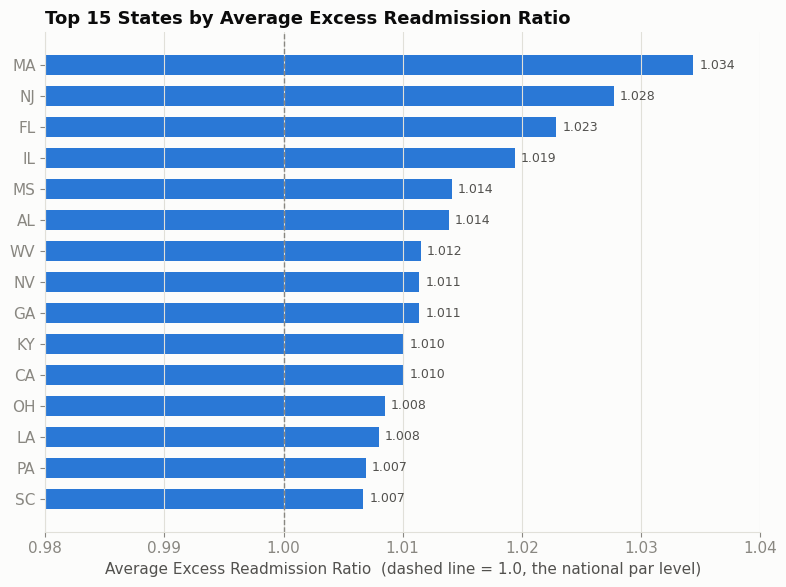

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

d = q1_top_states.sort_values("avg_excess_ratio")
ax.barh(d["state"], d["avg_excess_ratio"], color=CATEGORICAL[0], height=0.65)
ax.axvline(1.0, color=INK_MUTED, linewidth=1, linestyle="--")

for y, v in enumerate(d["avg_excess_ratio"]):
    ax.text(v + 0.0005, y, f"{v:.3f}", va="center", fontsize=9, color=INK_SECONDARY)

ax.set_xlim(0.98, 1.04)
ax.set_title("Top 15 States by Average Excess Readmission Ratio", loc="left", fontweight="bold", fontsize=13)
ax.set_xlabel("Average Excess Readmission Ratio  (dashed line = 1.0, the national par level)")
ax.grid(axis="y", visible=False)

fig.tight_layout()
plt.show()

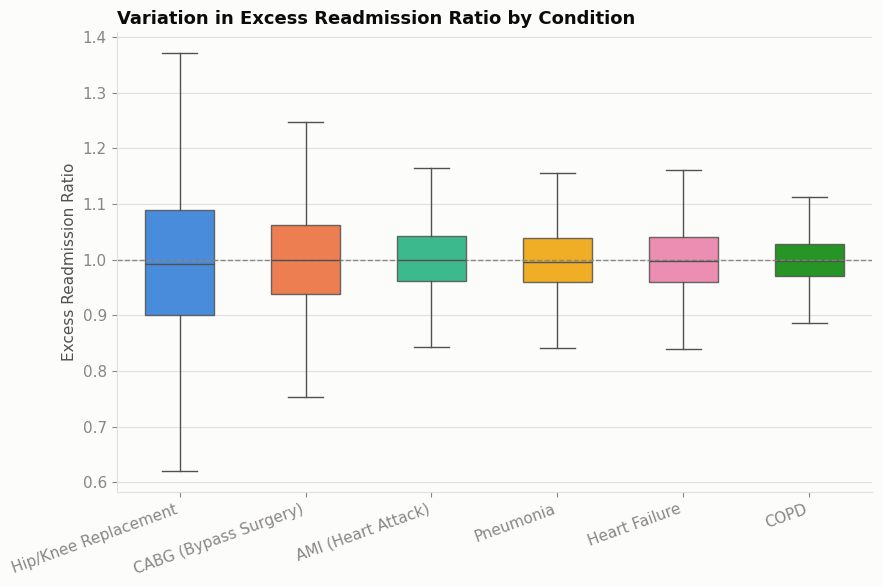

In [13]:
condition_order = q3_variation.sort_values("coefficient_of_variation", ascending=False)["condition"].tolist()
raw_ratios = pd.read_sql(
    "SELECT condition, excess_readmission_ratio FROM readmissions WHERE excess_readmission_ratio IS NOT NULL",
    conn,
)
groups = [raw_ratios.loc[raw_ratios["condition"] == c, "excess_readmission_ratio"].values for c in condition_order]

fig, ax = plt.subplots(figsize=(9, 6))
bp = ax.boxplot(groups, patch_artist=True, tick_labels=condition_order, showfliers=False, widths=0.55)

for patch, color in zip(bp["boxes"], CATEGORICAL):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_edgecolor(INK_SECONDARY)
for element in ["whiskers", "caps", "medians"]:
    plt.setp(bp[element], color=INK_SECONDARY)

ax.axhline(1.0, color=INK_MUTED, linewidth=1, linestyle="--")
ax.set_ylabel("Excess Readmission Ratio")
ax.set_title("Variation in Excess Readmission Ratio by Condition", loc="left", fontweight="bold", fontsize=13)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
ax.grid(axis="x", visible=False)

fig.tight_layout()
plt.show()

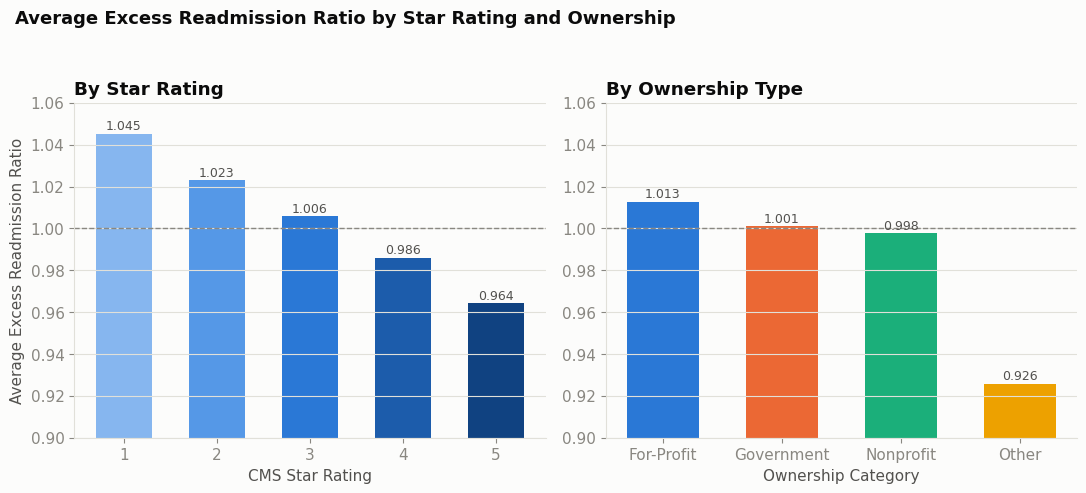

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ax = axes[0]
ax.bar(q2_by_rating["hospital_overall_rating"].astype(int).astype(str), q2_by_rating["avg_excess_ratio"],
       color=ORDINAL_BLUE, width=0.6)
ax.axhline(1.0, color=INK_MUTED, linewidth=1, linestyle="--")
for i, v in enumerate(q2_by_rating["avg_excess_ratio"]):
    ax.text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=9, color=INK_SECONDARY)
ax.set_ylim(0.90, 1.06)
ax.set_xlabel("CMS Star Rating")
ax.set_ylabel("Average Excess Readmission Ratio")
ax.set_title("By Star Rating", loc="left", fontweight="bold")
ax.grid(axis="x", visible=False)

ax2 = axes[1]
ax2.bar(q4_ownership["ownership_category"], q4_ownership["avg_excess_ratio"], color=CATEGORICAL[:4], width=0.6)
ax2.axhline(1.0, color=INK_MUTED, linewidth=1, linestyle="--")
for i, v in enumerate(q4_ownership["avg_excess_ratio"]):
    ax2.text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=9, color=INK_SECONDARY)
ax2.set_ylim(0.90, 1.06)
ax2.set_xlabel("Ownership Category")
ax2.set_title("By Ownership Type", loc="left", fontweight="bold")
ax2.grid(axis="x", visible=False)

fig.suptitle("Average Excess Readmission Ratio by Star Rating and Ownership", fontweight="bold", fontsize=13, x=0.02, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## 9. Key Findings

- **Geography matters, but only modestly.** Massachusetts, New Jersey, and Florida average the highest excess readmission ratios (~1.02–1.03); Idaho, North Dakota, and Maine average the lowest (~0.94–0.95). The full state-level range is under 10 percentage points.
- **Star rating is the strongest single predictor we tested.** Excess readmission ratio falls monotonically from 1.045 (1-star hospitals) to 0.964 (5-star hospitals), r ≈ -0.44 across ~2,600 rated hospitals.
- **Hip/Knee Replacement is the most variable condition by far** (coefficient of variation 0.155, vs. 0.045–0.096 for the other five conditions) — consistent with it being an elective procedure where surgical approach and rehab protocol vary widely by hospital.
- **Ownership type has a real but small effect.** For-profit hospitals average the worst readmission performance (1.013) of the three major ownership categories; nonprofit and government hospitals are close to par (~1.00).

## Data Sources & Notes

- Data: CMS Hospital Compare / Care Compare, FY 2026 Hospital Readmissions Reduction Program and Hospital General Information datasets, downloaded as CSVs into this project's root directory.
- The Excess Readmission Ratio is CMS's own risk-adjusted metric (predicted ÷ expected 30-day readmission rate) — it already accounts for each hospital's patient case mix, which is why it's usable for cross-hospital comparison as-is.
- All averages in this notebook are **unweighted** across hospitals/records — a hospital with 20 discharges counts the same as one with 2,000. A discharge-volume-weighted analysis could shift some of these rankings and would be a natural next step.
- ~6,600 of 18,330 readmission records (36%) have no usable ratio, mostly because CMS suppresses small counts (`"Too Few to Report"`) for patient privacy — these are excluded from all aggregates via `WHERE excess_readmission_ratio IS NOT NULL`.
- 10 facility IDs present in the readmissions file have no matching row in `hospital_general_info` (out of 3,055) and are naturally dropped by the `JOIN`s in Q2 and Q4 — a negligible 0.3% of hospitals.
- The "Other" ownership category in Q4 (Veterans Health Administration, Department of Defense, Tribal, Physician-owned) is a small sample (60 hospitals) — its strong result shouldn't be over-interpreted.

In [15]:
conn.close()